# Zestimatr Quickstart: Redshift Estimation from a Galaxy Spectrum

This tutorial walks you through using `zestimatr` to:

1. Load and visualize a high-resolution galaxy spectrum
2. Load a pretrained redshift estimation model
3. Predict the redshift with uncertainty
4. Compare the prediction to the ground truth
5. Detect and visualize emission lines
6. Compute evaluation metrics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

import zestimatr

## 1. Load and Visualize the Spectrum

We have a single galaxy spectrum from the JADES survey stored as an `.npz` file. Let's load it and see what's inside.

In [2]:
data = np.load("galaxy300_spectrum.npz")
print("Available keys:", list(data.keys()))
print(f"\nGalaxy ID: {int(data['id'])}")
print(f"RA, Dec: ({data['ra']:.4f}, {data['dec']:.4f})")
print(f"Ground truth redshift: z = {float(data['z']):.4f}")
print(f"Spectrum length: {data['flux_high'].shape[0]} pixels")
print(f"Wavelength range: {data['wavelength_high'].min():.2f} - {data['wavelength_high'].max():.2f} microns")

Available keys: ['flux_low', 'flux_low_err', 'flux_high', 'flux_high_err', 'flux_high_smoothed', 'flux_high_smoothed_err', 'id', 'ra', 'dec', 'z', 'wavelength_low', 'wavelength_high']

Galaxy ID: 3677
RA, Dec: (53.0703, -27.8456)
Ground truth redshift: z = 3.7023
Spectrum length: 2500 pixels
Wavelength range: 1.00 - 5.00 microns


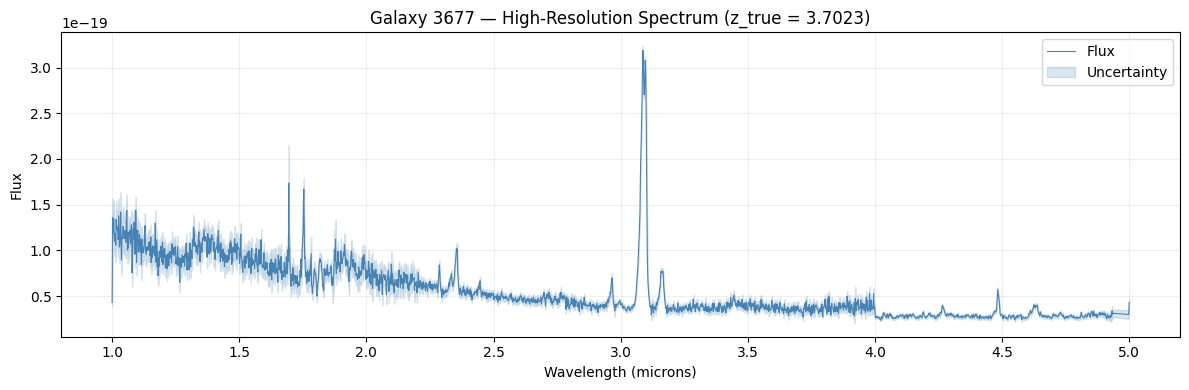

In [3]:
wavelength = data['wavelength_high']
flux = data['flux_high']
flux_err = data['flux_high_err']
z_true = float(data['z'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wavelength, flux, lw=0.8, color='steelblue', label='Flux')
ax.fill_between(wavelength, flux - flux_err, flux + flux_err,
                alpha=0.2, color='steelblue', label='Uncertainty')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Flux')
ax.set_title(f'Galaxy {int(data["id"])} — High-Resolution Spectrum (z_true = {z_true:.4f})')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 2. Load the Pretrained Model

`zestimatr.load_model` loads a trained checkpoint and returns the model along with the normalization parameters used during training.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

zhead, norm_params = zestimatr.load_model(
    zestimatr.download_pretrained(),
    device=device,
)

print(f"\nNormalization parameters:")
print(f"  z_mean = {norm_params['z_mean']:.4f}")
print(f"  z_std  = {norm_params['z_std']:.4f}")
print(f"  z_range = [{norm_params['z_min']:.4f}, {norm_params['z_max']:.4f}]")

Using device: cuda


/home/aryana/Documents/GitHub/CodeAstro_group_2/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Normalization parameters:
  z_mean = 3.3641
  z_std  = 1.7782
  z_range = [0.2439, 10.6030]


## 3. Prepare the Spectrum and Predict Redshift

Before feeding the spectrum to the model, we normalize it (zero mean, unit variance) — the same preprocessing applied during training. Then we use `zestimatr.predict_redshifts` to get the predicted redshift and its uncertainty.

In [5]:
# Normalize the flux (same as training preprocessing)
flux_norm = (flux - np.nanmean(flux)) / max(np.nanstd(flux), 1e-25)
flux_tensor = torch.tensor(flux_norm, dtype=torch.float32)

# Wrap in a DataLoader (predict_redshifts expects one)
dataset = TensorDataset(flux_tensor.unsqueeze(0), torch.tensor([z_true]))
dataloader = DataLoader(dataset, batch_size=1)

# Run inference
predictions = zestimatr.predict_redshifts(zhead, dataloader, norm_params, device)

z_pred = predictions['z_pred'][0]
z_unc = predictions['z_uncertainty'][0]

print(f"Predicted redshift: z = {z_pred:.4f} +/- {z_unc:.4f}")
print(f"True redshift:      z = {z_true:.4f}")
print(f"Absolute error:     |dz| = {abs(z_pred - z_true):.4f}")
print(f"Relative error:     |dz|/(1+z) = {abs(z_pred - z_true) / (1 + z_true):.4f}")

Predicting:   0%|          | 0/1 [00:00<?, ?it/s]

Predicting: 100%|██████████| 1/1 [00:00<00:00,  5.10it/s]

Predicting: 100%|██████████| 1/1 [00:00<00:00,  5.07it/s]

Predicted redshift: z = 3.6888 +/- 0.6967
True redshift:      z = 3.7023
Absolute error:     |dz| = 0.0135
Relative error:     |dz|/(1+z) = 0.0029


## 4. Visualize the Prediction

Let's plot the spectrum and annotate it with the predicted and true redshifts.

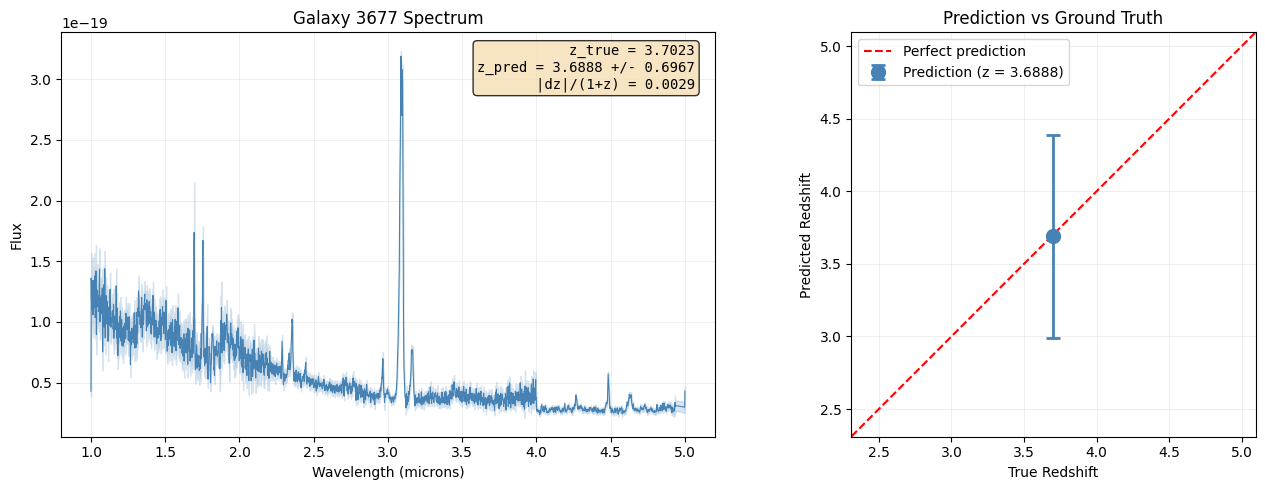

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: spectrum with redshift annotations
ax1.plot(wavelength, flux, lw=0.8, color='steelblue')
ax1.fill_between(wavelength, flux - flux_err, flux + flux_err,
                 alpha=0.2, color='steelblue')
ax1.set_xlabel('Wavelength (microns)')
ax1.set_ylabel('Flux')
ax1.set_title(f'Galaxy {int(data["id"])} Spectrum')
ax1.grid(True, alpha=0.2)

annotation = (
    f"z_true = {z_true:.4f}\n"
    f"z_pred = {z_pred:.4f} +/- {z_unc:.4f}\n"
    f"|dz|/(1+z) = {abs(z_pred - z_true) / (1 + z_true):.4f}"
)
ax1.text(0.97, 0.97, annotation, transform=ax1.transAxes,
         ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=10, family='monospace')

# Right: prediction vs truth (single point with error bar)
ax2.errorbar(z_true, z_pred, yerr=z_unc, fmt='o', color='steelblue',
             markersize=10, capsize=5, capthick=2, elinewidth=2,
             label=f'Prediction (z = {z_pred:.4f})')
ax2.plot([0, 12], [0, 12], 'r--', lw=1.5, label='Perfect prediction')
margin = max(2 * z_unc, 0.5)
ax2.set_xlim(z_true - margin, z_true + margin)
ax2.set_ylim(z_true - margin, z_true + margin)
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlabel('True Redshift')
ax2.set_ylabel('Predicted Redshift')
ax2.set_title('Prediction vs Ground Truth')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 5. Emission Line Detection

After estimating the redshift, `zestimatr` can identify emission lines present in the spectrum.
It shifts a catalog of common rest-frame lines (Ly-alpha, H-alpha, [O III], etc.) to the observed frame
using the predicted redshift and checks for flux peaks at the expected positions.

In [7]:
# Detect emission lines using the predicted redshift
lines = zestimatr.detect_emission_lines(wavelength, flux, z_pred)

print(f"Detected {len(lines)} emission lines at z = {z_pred:.4f}:\n")
lines

Detected 7 emission lines at z = 3.6888:



,line,rest_wavelength,obs_wavelength,peak_flux,snr
0,[O II],0.37270,1.747528,1.671338e-19,7.56
1,[O III] 5007,0.50070,2.347698,1.021944e-19,8.37
2,[N II] 6548,0.65480,3.070247,2.390653e-19,25.70
3,H$\alpha$,0.65628,3.077187,3.188459e-19,37.31
4,[N II] 6583,0.65830,3.086658,3.188459e-19,42.07
5,[S II] 6716,0.67160,3.149020,7.708720e-20,8.15
6,[S II] 6731,0.67310,3.156053,7.708720e-20,8.51


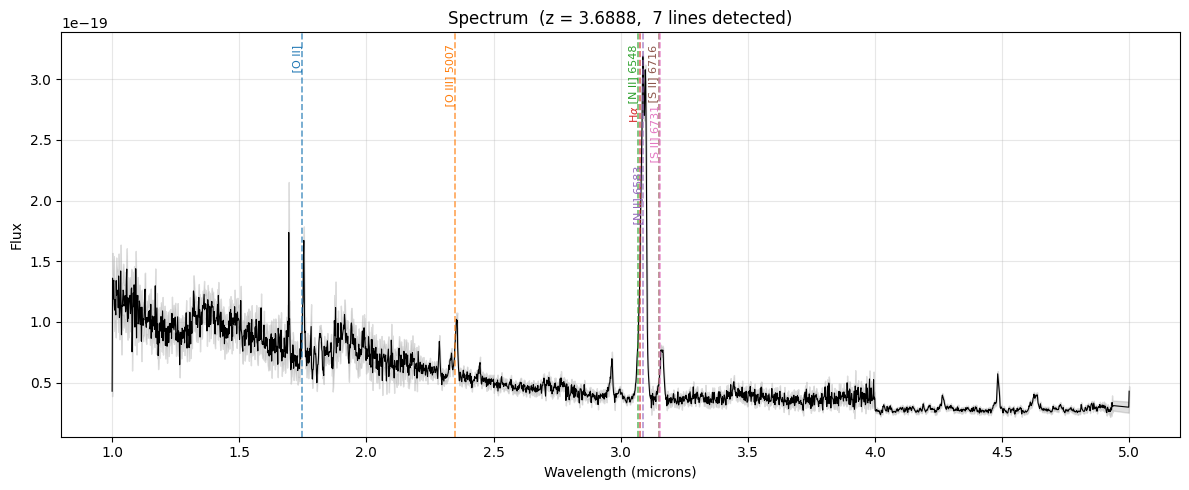

In [8]:
# Plot the spectrum with emission lines marked
zestimatr.plot_spectrum(wavelength, flux, z=z_pred, flux_err=flux_err);

## 6. Evaluate with Metrics

`zestimatr` provides two metric functions:
- **`compute_metrics`** — accuracy metrics: MAE, RMSE, NMAD, median relative error, outlier rate
- **`compute_calibration_metrics`** — uncertainty calibration: are the predicted error bars reliable?

These work on arrays of any size, so we can use them on our single prediction or on a full test set.

In [9]:
metrics = zestimatr.compute_metrics(predictions['z_pred'], predictions['z_true'])

print("Accuracy Metrics:")
print(f"  MAE:              {metrics['mae']:.4f}")
print(f"  RMSE:             {metrics['rmse']:.4f}")
print(f"  NMAD:             {metrics['nmad']:.4f}")
print(f"  Median |dz|/(1+z): {metrics['median_rel_error']:.4f}")
print(f"  Outlier rate:     {metrics['outlier_rate']:.1%}")
print(f"    (outlier = |dz|/(1+z) > 0.15)")

Accuracy Metrics:
  MAE:              0.0135
  RMSE:             0.0135
  NMAD:             0.0200
  Median |dz|/(1+z): 0.0029
  Outlier rate:     0.0%
    (outlier = |dz|/(1+z) > 0.15)


In [10]:
cal = zestimatr.compute_calibration_metrics(
    predictions['z_pred'], predictions['z_true'], predictions['z_uncertainty']
)

print("Calibration Metrics:")
print(f"  Calibration std:    {cal['calibration_std']:.3f}  (ideal = 1.0)")
print(f"  Calibration mean:   {cal['calibration_mean']:.3f}  (ideal = 0.0)")
print(f"  Median uncertainty: {cal['median_uncertainty']:.4f}")
print(f"  1-sigma coverage:   {cal['frac_1sigma']:.1%}  (ideal = 68.3%)")
print(f"  2-sigma coverage:   {cal['frac_2sigma']:.1%}  (ideal = 95.4%)")
print(f"  3-sigma coverage:   {cal['frac_3sigma']:.1%}  (ideal = 99.7%)")

Calibration Metrics:
  Calibration std:    0.000  (ideal = 1.0)
  Calibration mean:   -0.019  (ideal = 0.0)
  Median uncertainty: 0.6967
  1-sigma coverage:   100.0%  (ideal = 68.3%)
  2-sigma coverage:   100.0%  (ideal = 95.4%)
  3-sigma coverage:   100.0%  (ideal = 99.7%)


## Summary

In this tutorial we:

- Loaded a single galaxy spectrum from a `.npz` file
- Used `zestimatr.load_model` to load a pretrained redshift estimator
- Ran `zestimatr.predict_redshifts` to get a redshift prediction with uncertainty
- Compared the prediction to the ground truth visually and quantitatively
- Detected emission lines with `zestimatr.detect_emission_lines` and visualized them with `zestimatr.plot_spectrum`
- Evaluated accuracy with `zestimatr.compute_metrics` and uncertainty calibration with `zestimatr.compute_calibration_metrics`

For batch inference on many spectra, use `zestimatr.inference.InferenceDataset` to load an entire `.npz` file and pass it through the same pipeline.